# Replicating *Evaluating Commercial AI Chatbots as News Intermediaries*

This notebook reproduces every numerical result and visualization in the main
body of the manuscript from the raw model outputs released alongside the paper.
Running the notebook end-to-end takes well under a minute on a laptop and
produces:

1. **Headline tables** &mdash; overall model accuracy, regional accuracy, and the
   model$\,\times\,$region interaction.
2. **Citation-behavior results** &mdash; per-model citation rates and density,
   BBC-citation rates, top global domains, and per-region citation fingerprints.
3. **The splash figure** &mdash; the three-panel `splash_figure.pdf` rendered
   directly from the data.
4. **Web-search ablation** &mdash; the search-on/search-off contrast on the
   US&nbsp;\&&nbsp;Canada question set.
5. **Pipeline validation** &mdash; multiple-choice accuracy on the April&nbsp;6, 2026
   validation slice used to anchor the MC$\,\to\,$FR comparison.
6. **Adversarial robustness** &mdash; the adversarial-collapse and detection-vs-
   accuracy figures, constructed from per-model summary numbers (the
   per-question adversarial response files are not included in this release).

**Design.** Every figure and table is computed from a single, named pandas
`DataFrame` (`df` for the main eval, `df_baseline` for the no-search ablation,
`df_april` for the April&nbsp;6 validation). Helpers live near the top of the
notebook so that downstream cells read as a sequence of simple group-bys.


## 0&nbsp;&middot;&nbsp;Setup

We use only the standard scientific stack: `pandas`, `numpy`, and
`matplotlib`. No third-party plotting libraries are required.

In [1]:
from __future__ import annotations

import json
import os
import re
from collections import Counter
from pathlib import Path
from urllib.parse import urlparse

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook is run from the repo root; results/ and figures/ are sibling dirs.
ROOT = Path.cwd()
RES  = ROOT / "results"

print("Project root :", ROOT)
print("Results dir  :", RES)

Project root : <repo>
Results dir  : <repo>/results


### 0.1 Publication style

A single style block is applied once and reused by every figure. Colors come
from the *provenance* palette used by `splash_provenance.png` so that all
manuscript figures speak the same visual vocabulary.

In [2]:
mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         8.0,
    "axes.linewidth":    0.5,
    "axes.edgecolor":    "#1F1F1D",
    "xtick.color":       "#888780",
    "ytick.color":       "#1F1F1D",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size":  2.0,
    "ytick.major.size":  0.0,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.10,
})

# Provenance palette (unchanged across all figures for coherence).
PAL = {
    "primary":    "#1F1F1D",
    "secondary":  "#9E9E99",
    "accent":       "#A63232",
    "accent_soft":  "#3F4D5A",   # slate blue for "non-native language" rows
    "accent_strong":"#A63232",   # kept for emphatic cases (e.g. Hindi bar)
    "text_main":  "#1F1F1D",
    "text_mid":   "#5F5E5A",
    "text_muted": "#888780",
    "grid":       (136/255, 135/255, 128/255, 0.12),
    "stripe":     "#F2EEE6",          # pale eggshell (alt-row stripes; warm-cool tension w/ slate accents)
    "provider": {
        "google":    "#3B5E9E",
        "xai":       "#1F1F1D",
        "anthropic": "#BE6642",
        "openai":    "#2A8D72",
    },
}

# Distinct *shape* per model so the eye can track a single series across
# the dumbbell and density-per-region plots. Colour encodes the provider,
# shape disambiguates the two models within a provider (e.g. Flash vs Pro).
MODEL_STYLE = {
    "Gemini 3 Flash":    dict(marker="o", color=PAL["provider"]["google"],    size=24),
    "Gemini 3 Pro":      dict(marker="^", color=PAL["provider"]["google"],    size=26),
    "Grok 4":            dict(marker="P", color=PAL["provider"]["xai"],       size=32),
    "Claude 4.5 Sonnet": dict(marker="D", color=PAL["provider"]["anthropic"], size=22),
    "GPT-5":             dict(marker="s", color=PAL["provider"]["openai"],    size=22),
    "GPT-4o Mini":       dict(marker="o", color=PAL["provider"]["openai"],    size=24),
}

def panel_header(ax, letter, title, subtitle):
    if letter:
        ax.text(0.0, 1.22, letter, transform=ax.transAxes,
                fontsize=9.5, fontweight="bold", fontstyle="italic",
                color=PAL["text_main"], ha="left", va="bottom")
        title_x = 0.085
    else:
        title_x = 0.0
    ax.text(title_x, 1.22, title, transform=ax.transAxes,
            fontsize=8.5, fontweight="bold",
            color=PAL["text_main"], ha="left", va="bottom")
    if subtitle:
        ax.text(0.0, 1.06, subtitle, transform=ax.transAxes,
                fontsize=7.0, color=PAL["text_mid"], ha="left", va="bottom")

def clean_spines(ax):
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", colors=PAL["text_muted"])

# Figures land in figures/ as both PDF and PNG.
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", transparent=True)
    fig.savefig(FIG_DIR / f"{stem}.png",
                dpi=400, transparent=False, facecolor="white")
    print("wrote", stem)

### 0.2 Evaluation universe

We pin the canonical 14-day window (Feb&nbsp;9&ndash;22,&nbsp;2026), the six
regions, and the six production models. The same registries are reused for
the no-search ablation (which ships with a different OpenAI model identifier:
`gpt-5.2`, the static, non-search-augmented release) and for the April&nbsp;6
validation slice.

In [3]:
REGIONS = [
    ("uscanada", "US & Canada"),
    ("afrique",  "Afrique"),
    ("arabic",   "Arabic"),
    ("hindi",    "Hindi"),
    ("russian",  "Russian"),
    ("turkce",   "Turkish"),
]
REGION_DIR_TO_NAME = dict(REGIONS)
REGION_NAMES = [n for _, n in REGIONS]

MAIN_MODELS = [
    ("gemini-3-flash-preview",       "Gemini 3 Flash",    "google"),
    ("gemini-3-pro-preview",         "Gemini 3 Pro",      "google"),
    ("grok-4-0709",                  "Grok 4",            "xai"),
    ("claude-sonnet-4-5",            "Claude 4.5 Sonnet", "anthropic"),
    ("gpt-5-search-api",             "GPT-5",             "openai"),
    ("gpt-4o-mini-search-preview",   "GPT-4o Mini",       "openai"),
]
MODEL_DIR_TO_NAME     = {d: n for d, n, _ in MAIN_MODELS}
MODEL_DIR_TO_PROVIDER = {d: p for d, _, p in MAIN_MODELS}
MODEL_NAMES           = [n for _, n, _ in MAIN_MODELS]

# Search-disabled (parametric-only) variants.  Note that the OpenAI baseline
# uses `gpt-5.2` (the static release, no native search) since the search API
# variant does not expose a "search off" mode.
BASELINE_MODELS = [
    ("gemini-3-pro-preview-baseline", "Gemini 3 Pro"),
    ("grok-4-0709-baseline",          "Grok 4"),
    ("claude-sonnet-4-5-baseline",    "Claude 4.5 Sonnet"),
    ("gpt-5.2-baseline",              "GPT-5"),
]
BASELINE_DIR_TO_NAME = dict(BASELINE_MODELS)

# 14 canonical evaluation days: Feb 9–22, 2026.
EVAL_DAYS = [f"february_{d}" for d in range(9, 23)]

## 1&nbsp;&middot;&nbsp;Loading the raw outputs

Each `(region, model, day)` cell is a single newline-delimited JSON file under
`results/<region>/<model>/<day>_outputs.jsonl`. A row contains the question
prompt (`input`), the gold answer (`correct_answer`), the model's raw text
(`model_output`), and book-keeping metadata. The two extraction routines
below turn that raw text into a parseable `(answer_letter, citations)` pair.

In [4]:
ANS_TAG_RE     = re.compile(r"<final_answer>(.*?)</final_answer>", re.IGNORECASE | re.DOTALL)
LETTER_PAREN   = re.compile(r"\(\s*([A-Fa-f])\s*\)")
LETTER_STRICT  = re.compile(r"^\s*\(?\s*([A-Fa-f])\s*\)?(?:\s|$|[\.,])")
LETTER_TAIL    = re.compile(r"\(\s*([A-Fa-f])\s*\)\s*$", re.MULTILINE)

def extract_answer(text: str | None) -> str | None:
    """Return the upper-case option letter (A-F) selected by the model.

    Models embed their final choice inside <final_answer> ... </final_answer>.
    Inside the tag we prefer an explicit ``(X)`` token (the convention all
    six evaluated models follow when they actually answer); we fall back
    to a strict leading bare letter (``A``, ``A.``, etc.) when the tag
    contains a single character. If neither matches, the row is treated as
    unparseable (returns ``None``). Without that strictness the prior
    permissive regex spuriously extracted letters from refusal text such
    as "I cannot answer..." -> "C" or "Final answer: (B)" -> "F" (the F
    in "Final"); see the regression tests below.
    """
    if not isinstance(text, str):
        return None
    m = ANS_TAG_RE.search(text)
    if m:
        inner = m.group(1)
        paren_matches = LETTER_PAREN.findall(inner)
        if paren_matches:
            return paren_matches[0].upper()
        m2 = LETTER_STRICT.match(inner.lstrip())
        if m2:
            return m2.group(1).upper()
        return None
    matches = LETTER_TAIL.findall(text)
    return matches[-1].upper() if matches else None

# This `extract_answer` function is duplicated verbatim in the other two
# notebooks. The synthetic regression tests below break loudly if anyone
# changes the regex.
assert extract_answer("<final_answer>A</final_answer>") == "A"
assert extract_answer("<final_answer>(B)</final_answer>") == "B"
assert extract_answer("<final_answer>  C  </final_answer>") == "C"
assert extract_answer("<final_answer>(D) An evil operative</final_answer>") == "D"
assert extract_answer("<final_answer>e</final_answer>") == "E"
assert extract_answer("<FINAL_ANSWER>F</FINAL_ANSWER>") == "F"
assert extract_answer("<final_answer>\n(A)\n</final_answer>") == "A"
assert extract_answer("Reasoning... (D)\nFinal: (A)") == "A"        # fallback path
assert extract_answer("I think it's A but maybe B") is None         # no tag, no LETTER_TAIL
assert extract_answer(None) is None
assert extract_answer("") is None
assert extract_answer("<final_answer></final_answer>") is None
assert extract_answer("<final_answer>G</final_answer>") is None     # out of A-F
# Regression tests for the v2 strict extractor: refusal / preamble strings
# must NOT spuriously extract a letter out of words like "Final" or "cannot".
assert extract_answer("<final_answer>Final answer: (B)</final_answer>") == "B"
assert extract_answer("<final_answer>The answer is C</final_answer>") is None
assert extract_answer("<final_answer>Unable to determine from available sources</final_answer>") is None
assert extract_answer("<final_answer>I cannot answer based on retrieved evidence.</final_answer>") is None
assert extract_answer("<final_answer>(B) is consistent with the article.</final_answer>") == "B"
assert extract_answer("<final_answer>D.</final_answer>") == "D"
print("extract_answer parity-lock tests pass")


extract_answer parity-lock tests pass


In [5]:
from urllib.parse import parse_qs, urlencode

URL_RE = re.compile(r"https?://[^\s\)\]\}\>\"\'`<]+")

# Tracking-parameter names that some providers' search tools attach to URLs at
# fetch time (notably OpenAI: ``?utm_source=openai``). We strip these for the
# purpose of within-response deduplication only — a URL appearing once with a
# tracking parameter and once without is the same logical citation. The
# original URL form is preserved for downstream domain extraction and display;
# we use the canonicalised string only as a dedup key.
TRACKING_PARAMS = {
    "utm_source", "utm_medium", "utm_campaign", "utm_term", "utm_content",
    "utm_id", "utm_name", "utm_brand", "utm_social", "utm_pubreferrer",
    "fbclid", "gclid", "mc_cid", "mc_eid", "_ga", "ref", "ref_src",
    "_hsenc", "_hsmi", "yclid", "yandex_clid", "mkt_tok", "cmpid",
    "cid", "src", "srcid", "email_source", "twclid", "wt_zmc",
    "spm", "share_source",
}

def _canonical_key(url: str) -> str | None:
    """Canonical dedup key for a URL: lowercase host, no `www.` prefix, no
    trailing slash, no tracking-only query parameters, remaining params sorted.
    Used ONLY as a within-response dedup key — the original URL is preserved
    for downstream domain extraction and display.
    """
    try:
        p = urlparse(url)
    except ValueError:
        return None
    host = p.netloc.lower()
    if host.startswith("www."):
        host = host[4:]
    if not host:
        return None
    path = p.path.rstrip("/")
    if p.query:
        kept = [(k, v) for k, vs in parse_qs(p.query, keep_blank_values=True).items()
                for v in vs if k.lower() not in TRACKING_PARAMS]
        query = urlencode(sorted(kept))
    else:
        query = ""
    return f"{host}{path}{('?' + query) if query else ''}"

def normalize_domain(url: str | None) -> str | None:
    """Canonicalize a URL to a comparable domain.

    * strips a leading "www.";
    * collapses every BBC subdomain (and bbc.co.uk) to "bbc.com";
    * resolves Vertex AI grounding redirects to the literal token
      "vertexaisearch.cloud.google.com" — Google's API returns an opaque
      redirect URL whose destination is not exposed, so we keep the redirect
      itself as a single accountable "domain" rather than discarding it.
    """
    if not url:
        return None
    url = url.rstrip(").,;:!?\\\"'`>]")
    try:
        host = urlparse(url).netloc.lower()
    except ValueError:
        return None
    if not host:
        return None
    if host.startswith("www."):
        host = host[4:]
    if "vertexaisearch.cloud.google.com" in host:
        return "vertexaisearch.cloud.google.com"
    if host == "bbc.com" or host.endswith(".bbc.com") or host == "bbc.co.uk" or host.endswith(".bbc.co.uk"):
        return "bbc.com"
    return host

def extract_urls(text: str | None) -> list[str]:
    """Return de-duplicated URLs in *order of appearance*.

    Deduplication uses a canonicalised key (`_canonical_key`) that strips
    `www.`, trailing slashes, and tracking-only query parameters, so that a
    URL appearing once with ``?utm_source=openai`` and once without it counts
    as a single citation. The function still returns the URL in its original
    form (the first variant seen) so downstream domain extraction and display
    are unchanged.
    """
    if not isinstance(text, str):
        return []
    seen, out = set(), []
    for u in URL_RE.findall(text):
        u = u.rstrip(").,;:!?\\\"'`>]")
        key = _canonical_key(u)
        if key and key not in seen:
            seen.add(key)
            out.append(u)
    return out

In [6]:
# ── Gold-label errata (publicly documented corrections) ──────────────
# Five gold labels in the released JSONL warrant correction. The fixes are
# applied at load time so the on-disk JSONL remains a faithful record of the
# original 14-day evaluation prompt + gold pair, while published numbers use
# the corrected gold. The errata are keyed by (region_dir, day, q_idx).
#
#   1. ("hindi", "february_21", 19): options (C) and (E) both read
#      "237 ट्यूटर"; original gold was (E), so any model that read the option
#      list top-down and returned (C) was penalised despite naming the
#      correct value. Both letters now count as correct.
#   2. ("afrique", "february_9", 14): options (D) and (E) both read
#      "Pierre Robert"; original gold was (E). Both letters now count as
#      correct.
#   3. ("arabic", "february_14", 20): the explanation field in the JSONL
#      verbatim quotes option (B) ("It is not our war..."), but the gold was
#      mislabeled as (A). Corrected to (B).
#   4. ("uscanada", "february_13", 6): the original `correct_answer` field
#      was a question-generator scaffolding leak ("(B) [Note: rephrase ...]")
#      that no model output ever matches; the explanation field clearly
#      identifies "Deadpool fighting a dragon" as the option NOT mentioned.
#      Corrected to (A).
#   5. ("uscanada", "february_20", 23) is *not* corrected here: the BBC
#      article appears (per the JSONL explanation) to support 240 km off
#      Oman rather than the stored 700 km, but the public release defers
#      this case to author confirmation.
GOLD_ERRATA = {
    ("hindi",    "february_21", 19): {"C", "E"},
    ("afrique",  "february_9",  14): {"D", "E"},
    ("arabic",   "february_14", 20): "B",
    ("uscanada", "february_13",  6): "A",
}

def gold_with_errata(region_dir, day, q_idx, raw_correct_answer):
    """Return either a single letter A-F or a frozenset of letters; None if unparseable."""
    key = (region_dir, day, q_idx)
    if key in GOLD_ERRATA:
        v = GOLD_ERRATA[key]
        return frozenset(v) if isinstance(v, (set, frozenset)) else v
    if not isinstance(raw_correct_answer, str):
        return None
    s = raw_correct_answer.strip().strip("()").strip().upper()
    return s[0] if s and s[0] in "ABCDEF" else None


In [7]:
def _load_jsonl(path: Path) -> list[dict]:
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def build_records(model_pool, *, days=None, region_subset=None,
                  baseline=False, lookup_name=None):
    """Yield one dict per (region, model, day, question) cell.

    ``model_pool``    : iterable of model directory names to load.
    ``days``          : list of day-stems (default: 14-day eval window).
    ``region_subset`` : restrict to a list of region directory names.
    ``baseline``      : tags rows as no-search baselines.
    ``lookup_name``   : optional dict mapping dir -> display name.
                         Defaults to MODEL_DIR_TO_NAME merged with
                         BASELINE_DIR_TO_NAME.
    """
    days = days or EVAL_DAYS
    regions = region_subset or [r for r, _ in REGIONS]
    name_map = {**MODEL_DIR_TO_NAME, **BASELINE_DIR_TO_NAME}
    if lookup_name:
        name_map.update(lookup_name)

    for r in regions:
        for m in model_pool:
            d = RES / r / m
            if not d.is_dir():
                continue
            for day in days:
                fn = d / f"{day}_outputs.jsonl"
                if not fn.exists():
                    continue
                for q_idx, row in enumerate(_load_jsonl(fn)):
                    mo = row.get("model_output")
                    pred = extract_answer(mo)
                    correct = gold_with_errata(r, day, q_idx, row.get("correct_answer"))
                    urls = extract_urls(mo)
                    domains = [d for d in (normalize_domain(u) for u in urls) if d]
                    yield {
                        "region_dir": r,
                        "region":     REGION_DIR_TO_NAME[r],
                        "model_dir":  m,
                        "model":      name_map.get(m, m),
                        "provider":   MODEL_DIR_TO_PROVIDER.get(m, ""),
                        "baseline":   baseline,
                        "day":        day,
                        "q_idx":      q_idx,
                        "correct":    correct,
                        "predicted":  pred,
                        "is_correct": (
                            pred is not None and correct is not None and (
                                pred in correct if isinstance(correct, frozenset) else pred == correct
                            )
                        ),
                        "n_urls":     len(urls),
                        "n_unique_domains": len(set(domains)),
                        "domains":    domains,
                        "urls":       urls,
                        "source_url": row.get("url"),
                    }

### 1.1 Build the master eval `DataFrame`

This is the canonical 12,600-row table used for every Section&nbsp;3 result in
the paper.

In [8]:
df = pd.DataFrame(build_records([m for m, _, _ in MAIN_MODELS]))
df["model"]  = pd.Categorical(df["model"],  categories=MODEL_NAMES,  ordered=True)
df["region"] = pd.Categorical(df["region"], categories=REGION_NAMES, ordered=True)

assert len(df) == 6 * 6 * 14 * 25, f"expected 12,600 rows, got {len(df)}"
print(f"main eval: {len(df):,} rows  ({df['model'].nunique()} models × "
      f"{df['region'].nunique()} regions × {df['day'].nunique()} days × 25 questions)")

display(df.head(3))

main eval: 12,600 rows  (6 models × 6 regions × 14 days × 25 questions)


,region_dir,region,model_dir,model,provider,baseline,day,q_idx,correct,predicted,is_correct,n_urls,n_unique_domains,domains,urls,source_url
0,uscanada,US & Canada,gemini-3-flash-preview,Gemini 3 Flash,google,False,february_9,0,A,A,True,5,5,"[cbsnews.com, mediaite.com, washingtontimes.co...",[https://www.cbsnews.com/news/ghislaine-maxwel...,https://www.bbc.com/news/articles/cvgv5yre39zo
1,uscanada,US & Canada,gemini-3-flash-preview,Gemini 3 Flash,google,False,february_9,1,B,B,True,6,6,"[aa.com.tr, hellenicshippingnews.com, gcaptain...",[https://www.aa.com.tr/en/americas/us-boards-s...,https://www.bbc.com/news/articles/c5y4dyp0765o
2,uscanada,US & Canada,gemini-3-flash-preview,Gemini 3 Flash,google,False,february_9,2,C,C,True,5,5,"[wearememorial.com, studentsforlife.org, natio...",[https://www.wearememorial.com/from-the-nicu-t...,https://www.bbc.com/sport/american-football/ar...


## 2&nbsp;&middot;&nbsp;Headline accuracy

We average each cell first within (model, day), reporting $\pm$&nbsp;1&nbsp;SD
across days, and only then average over models or regions. This preserves the
day-level variability and keeps the standard deviations interpretable.


In [9]:
# Per-day accuracy at the (model, day) level — building block for Table 2.
day_model = (df.groupby(["model", "day"])["is_correct"].mean() * 100).reset_index()

table_model = (
    day_model.groupby("model")["is_correct"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "Acc. (%)", "std": "± SD"})
)
errors_per_day = (df.assign(err=~df["is_correct"])
                    .groupby(["model", "day"])["err"].sum()
                    .groupby(level=0).mean()
                    .rename("Errors/Day"))
table_model = table_model.join(errors_per_day).sort_values("Acc. (%)", ascending=False)

print("Table 2  ·  Overall model accuracy")
display(table_model.round({"Acc. (%)": 1, "± SD": 1, "Errors/Day": 1}))

Table 2  ·  Overall model accuracy


,Acc. (%),± SD,Errors/Day
model,,,
Gemini 3 Flash,95.6,1.7,6.6
Grok 4,95.0,1.2,7.4
Gemini 3 Pro,93.7,2.1,9.4
Claude 4.5 Sonnet,90.4,2.8,14.4
GPT-5,85.0,2.9,22.6
GPT-4o Mini,69.0,2.7,46.5


In [10]:
# Per-day accuracy at the (region, day) level — building block for Table 3.
day_region = (df.groupby(["region", "day"])["is_correct"].mean() * 100).reset_index()

table_region = (
    day_region.groupby("region")["is_correct"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "Acc. (%)", "std": "± SD"})
)
err_region = (df.assign(err=~df["is_correct"])
                .groupby(["region", "day"])["err"].sum()
                .groupby(level=0).mean()
                .rename("Errors/Day"))
table_region = table_region.join(err_region).sort_values("Acc. (%)", ascending=False)

print("Table 3  ·  Accuracy by region")
display(table_region.round({"Acc. (%)": 1, "± SD": 1, "Errors/Day": 1}))

Table 3  ·  Accuracy by region


,Acc. (%),± SD,Errors/Day
region,,,
US & Canada,91.3,3.8,13.0
Turkish,90.0,2.6,14.9
Russian,89.9,2.7,15.2
Arabic,89.2,2.7,16.1
Afrique,88.9,4.1,16.6
Hindi,79.3,4.2,31.0


### 2.1 Model$\,\times\,$Region heatmap

The model$\,\times\,$region interaction renders as a heatmap so the structure
of the *Hindi gap* &mdash; that every row's minimum sits in the same column &mdash;
is visible at a glance. Cell labels show the 14-day mean accuracy with $\pm$ 1 SD
across days.


In [11]:
# Compute the cell-by-cell mean accuracy and SD (averaged over days).
cell = (df.groupby(["model", "region", "day"])["is_correct"].mean() * 100).reset_index()
heat   = cell.groupby(["model", "region"])["is_correct"].mean().unstack("region")
heat_sd = cell.groupby(["model", "region"])["is_correct"].std().unstack("region")
heat   = heat.reindex(MODEL_NAMES)[REGION_NAMES]
heat_sd = heat_sd.reindex(MODEL_NAMES)[REGION_NAMES]

print("Table 4  ·  Model × Region accuracy (%)")
display(heat.round(1))

Table 4  ·  Model × Region accuracy (%)


region,US & Canada,Afrique,Arabic,Hindi,Russian,Turkish
model,,,,,,
Gemini 3 Flash,96.6,94.9,97.7,90.0,98.0,96.3
Gemini 3 Pro,96.0,94.3,90.9,88.0,97.4,95.7
Grok 4,96.9,96.0,97.7,86.0,98.0,95.7
Claude 4.5 Sonnet,95.7,90.6,91.1,82.0,90.6,92.6
GPT-5,88.6,85.7,87.4,75.4,86.9,85.7
GPT-4o Mini,74.3,72.0,70.6,54.6,68.3,74.3


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_model_region_heatmap


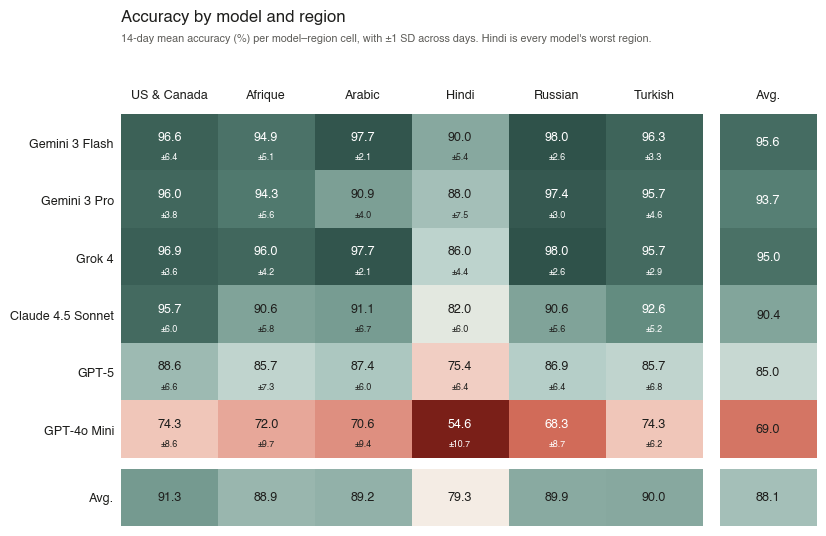

In [12]:
# Diverging colormap: low accuracy renders crimson, mid renders cream, high renders teal.
# A single ramp is applied uniformly to every cell; shade encodes the cell's accuracy
# on the same axis as the rest of the matrix.
import matplotlib as mpl
_LC = mpl.colors.LinearSegmentedColormap.from_list
HEAT_CMAP = _LC("heat", ["#7A1F18", "#C7503D", "#F0BFB2", "#F5F2EA",
                          "#B8D0CA", "#5A8478", "#1F3F38"])

def _cell_color(cmap, v, vmin=60, vmax=100):
    norm = max(0.0, min(1.0, (v - vmin) / (vmax - vmin)))
    return cmap(norm)

def plot_heatmap(heat, heat_sd, stem):
    cmap = HEAT_CMAP

    regions  = list(heat.columns)
    models   = list(heat.index)
    row_avg  = heat.mean(axis=1)
    col_avg  = heat.mean(axis=0)
    grand    = heat.values.mean()

    n_r, n_c = len(models), len(regions)

    width_ratios  = [1] * n_c + [0.18, 1]    # matrix + gutter + avg col
    height_ratios = [1] * n_r + [0.18, 1]    # matrix + gutter + avg row

    fig = plt.figure(figsize=(0.82 * n_c + 4.0, 0.60 * n_r + 2.2))
    gs = fig.add_gridspec(len(height_ratios), len(width_ratios),
                          width_ratios=width_ratios,
                          height_ratios=height_ratios,
                          left=0.19, right=0.97, top=0.79, bottom=0.08,
                          wspace=0.0, hspace=0.0)

    # Main matrix
    axM = fig.add_subplot(gs[:n_r, :n_c])
    img = np.zeros((n_r, n_c, 4))
    for i, m in enumerate(models):
        for j, r in enumerate(regions):
            img[i, j] = _cell_color(cmap, heat.iat[i, j])
    axM.imshow(img, aspect="auto", interpolation="nearest")

    row_max = heat.max(axis=1)
    for i, m in enumerate(models):
        for j, r in enumerate(regions):
            v  = heat.iat[i, j]
            sd = heat_sd.iat[i, j]
            best = abs(v - row_max[m]) < 1e-9
            bg = img[i, j]
            luminance = 0.2126*bg[0] + 0.7152*bg[1] + 0.0722*bg[2]
            txt_c = "white" if luminance < 0.52 else PAL["text_main"]
            axM.text(j, i - 0.10, f"{v:.1f}",
                     ha="center", va="center", fontsize=9.0,
                     fontweight=("bold" if best else "regular"),
                     color=txt_c)
            axM.text(j, i + 0.25, f"±{sd:.1f}",
                     ha="center", va="center", fontsize=6.4, color=txt_c)

    axM.set_xticks([]); axM.set_yticks(range(n_r))
    axM.set_yticklabels(models, fontsize=9)
    axM.tick_params(axis="y", length=0, pad=5)
    for s in axM.spines.values(): s.set_visible(False)

    for j, r in enumerate(regions):
        axM.text(j, -0.72, r, ha="center", va="bottom",
                 fontsize=9, color=PAL["text_main"])

    # Aggregate column (per-model avg across regions)
    axAvgCol = fig.add_subplot(gs[:n_r, n_c + 1])
    img_col = np.array([[_cell_color(cmap, row_avg[m])] for m in models])
    axAvgCol.imshow(img_col, aspect="auto", interpolation="nearest")
    for i, m in enumerate(models):
        v = row_avg[m]
        bg = img_col[i, 0]
        luminance = 0.2126*bg[0] + 0.7152*bg[1] + 0.0722*bg[2]
        txt_c = "white" if luminance < 0.52 else PAL["text_main"]
        axAvgCol.text(0, i, f"{v:.1f}",
                      ha="center", va="center",
                      fontsize=9.0, fontweight="bold", color=txt_c)
    axAvgCol.set_xticks([]); axAvgCol.set_yticks([])
    axAvgCol.text(0, -0.72, "Avg.", ha="center", va="bottom",
                  fontsize=9, fontweight="bold", color=PAL["text_main"])
    for s in axAvgCol.spines.values(): s.set_visible(False)

    # Aggregate row (per-region avg across models)
    axAvgRow = fig.add_subplot(gs[n_r + 1, :n_c])
    img_row = np.zeros((1, n_c, 4))
    for j, r in enumerate(regions):
        img_row[0, j] = _cell_color(cmap, col_avg[r])
    axAvgRow.imshow(img_row, aspect="auto", interpolation="nearest")
    for j, r in enumerate(regions):
        v = col_avg[r]
        bg = img_row[0, j]
        luminance = 0.2126*bg[0] + 0.7152*bg[1] + 0.0722*bg[2]
        txt_c = "white" if luminance < 0.52 else PAL["text_main"]
        axAvgRow.text(j, 0, f"{v:.1f}",
                      ha="center", va="center",
                      fontsize=9.0, fontweight="bold", color=txt_c)
    axAvgRow.set_xticks([]); axAvgRow.set_yticks([0])
    axAvgRow.set_yticklabels(["Avg."], fontsize=9, fontweight="bold")
    axAvgRow.tick_params(axis="y", length=0, pad=5)
    for s in axAvgRow.spines.values(): s.set_visible(False)

    # Grand mean
    axG = fig.add_subplot(gs[n_r + 1, n_c + 1])
    axG.imshow([[_cell_color(cmap, grand)]], aspect="auto", interpolation="nearest")
    bg = _cell_color(cmap, grand)
    luminance = 0.2126*bg[0] + 0.7152*bg[1] + 0.0722*bg[2]
    txt_c = "white" if luminance < 0.52 else PAL["text_main"]
    axG.text(0, 0, f"{grand:.1f}",
             ha="center", va="center",
             fontsize=9.2, fontweight="bold", color=txt_c)
    axG.set_xticks([]); axG.set_yticks([])
    for s in axG.spines.values(): s.set_visible(False)

    # Title strip
    fig.text(0.19, 0.95, "Accuracy by model and region",
             fontsize=12, fontweight="bold", color=PAL["text_main"])
    fig.text(0.19, 0.915,
             "14-day mean accuracy (%) per model–region cell, "
             "with ±1 SD across days. Hindi is every model's worst region.",
             fontsize=7.8, color=PAL["text_mid"])

    savefig(fig, stem)
    plt.show()

plot_heatmap(heat, heat_sd, "fig_model_region_heatmap")


## 3&nbsp;&middot;&nbsp;Splash figure

The three-panel splash is the visual headline of the paper. We re-render it
here from the same `df` so that any future revision to the eval propagates
automatically.


In [13]:
PROVIDERS = {n: p for _, n, p in MAIN_MODELS}

def draw_accuracy_panel(ax):
    s = table_model["Acc. (%)"].sort_values(ascending=False)
    models = list(s.index)
    accs   = s.values
    y      = np.arange(len(models))[::-1]
    colors = [PAL["provider"][PROVIDERS[m]] for m in models]

    ax.barh(y, accs, height=0.62, color=colors, edgecolor="none")
    for yi, v, c in zip(y, accs, colors):
        ax.text(v + 0.9, yi, f"{v:.1f}", va="center", ha="left",
                fontsize=7, fontweight="bold", color=c)

    ax.set_yticks(y); ax.set_yticklabels(models, fontsize=7.2, color=PAL["text_main"])
    ax.set_xlim(60, 103); ax.set_xticks([60, 70, 80, 90, 100])
    ax.set_xticklabels([f"{x}%" for x in [60, 70, 80, 90, 100]], fontsize=6.8)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)
    panel_header(ax, "a", "Accuracy on emerging news",
                 f"14 days · 2,100 questions · web search enabled.")

def draw_region_panel(ax):
    s = table_region["Acc. (%)"].sort_values(ascending=False)
    regions = list(s.index); vals = s.values
    y = np.arange(len(regions))[::-1]
    colors = [PAL["accent"] if r == "Hindi" else PAL["primary"] for r in regions]
    ax.barh(y, vals, height=0.62, color=colors, edgecolor="none")
    for yi, v, r in zip(y, vals, regions):
        col = PAL["accent"] if r == "Hindi" else PAL["text_main"]
        ax.text(v + 0.9, yi, f"{v:.1f}", va="center", ha="left",
                fontsize=7, fontweight="bold", color=col)
    ax.set_yticks(y); ax.set_yticklabels(regions, fontsize=7.2, color=PAL["text_main"])
    for tl, r in zip(ax.get_yticklabels(), regions):
        if r == "Hindi":
            tl.set_color(PAL["accent"]); tl.set_fontweight("bold")
    ax.set_xlim(60, 103); ax.set_xticks([60, 70, 80, 90, 100])
    ax.set_xticklabels([f"{x}%" for x in [60, 70, 80, 90, 100]], fontsize=6.8)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)
    panel_header(ax, "b", "Accuracy by region",
                 "Hindi is every model's worst region.")

In [14]:
# ------------------------------------------------------------------
# Top cited domains globally — Panel C of the splash + Table 5.
# ------------------------------------------------------------------
exploded = df.explode("domains").dropna(subset=["domains"])
N_DAYS   = df["day"].nunique()  # 14

# Cites/day across the entire eval (all models, all regions).
domain_cites_per_day = (exploded.groupby("domains").size() / N_DAYS).sort_values(ascending=False)
domain_share = (exploded.groupby("domains").size() / len(exploded) * 100).sort_values(ascending=False)
top_domains = pd.DataFrame({
    "Cites/Day": domain_cites_per_day,
    "Share (%)": domain_share,
}).sort_values("Cites/Day", ascending=False).head(15)

print("Table 5  ·  Top-15 cited domains globally")
display(top_domains.round(2))

Table 5  ·  Top-15 cited domains globally


,Cites/Day,Share (%)
domains,,
en.wikipedia.org,79.86,3.48
vertexaisearch.cloud.google.com,63.36,2.76
bbc.com,61.79,2.69
theguardian.com,50.29,2.19
aljazeera.com,26.93,1.17
cbsnews.com,26.00,1.13
apnews.com,21.64,0.94
aa.com.tr,19.86,0.87
washingtonpost.com,17.71,0.77


In [15]:
# Human-readable labels for the splash. We exclude
# `vertexaisearch.cloud.google.com` because it's an opaque API redirect,
# not a primary source — but it remains in the diagnostic table above.
SPLASH_DOMAINS = [
    # (host, label, primary_content_language).
    # `aljazeera.com` is Al Jazeera's English-language flagship; the Arabic
    # flagship is `aljazeera.net` (separately tracked, ~14.7 cites/day,
    # outside the top 8). Tagging by the *content* language readers see
    # on the page, not by network/brand origin.
    ("en.wikipedia.org",     "Wikipedia (en)",       "en"),
    ("bbc.com",              "BBC (en)",             "en"),
    ("theguardian.com",      "The Guardian (en)",    "en"),
    ("aljazeera.com",        "Al Jazeera (en)",      "en"),
    ("cbsnews.com",          "CBS News (en)",        "en"),
    ("apnews.com",           "AP News (en)",         "en"),
    ("aa.com.tr",            "Anadolu Agency (tr)",  "tr"),
    ("washingtonpost.com",   "Washington Post (en)", "en"),
]

def draw_domains_panel(ax):
    rows = [(label, domain_cites_per_day.get(host, 0.0), lang)
            for host, label, lang in SPLASH_DOMAINS]
    names  = [r[0] for r in rows]
    vals   = [r[1] for r in rows]
    langs  = [r[2] for r in rows]
    y = np.arange(len(rows))[::-1]
    bar_colors = [PAL["primary"] if l == "en" else PAL["accent"] for l in langs]

    ax.barh(y, vals, height=0.62, color=bar_colors, edgecolor="none")
    for yi, v, l in zip(y, vals, langs):
        col = PAL["text_main"] if l == "en" else PAL["accent"]
        ax.text(v + 1.5, yi, f"{v:.1f}", va="center", ha="left",
                fontsize=7, fontweight="bold", color=col)

    ax.set_yticks(y); ax.set_yticklabels(names, fontsize=7.2, color=PAL["text_main"])
    for tl, l in zip(ax.get_yticklabels(), langs):
        if l != "en":
            tl.set_color(PAL["accent"])

    ax.set_xlim(0, max(vals) * 1.18); ax.set_xticks([0, 25, 50, 75])
    ax.set_xticklabels(["0", "25", "50", "75"], fontsize=6.8)
    ax.set_xlabel("Citations per day", fontsize=7, color=PAL["text_mid"], labelpad=2)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)
    panel_header(ax, "c", "Most-cited domains",
                 f"{sum(1 for _, _, l in SPLASH_DOMAINS if l == 'en')} of top 8 are primarily English.")

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote splash_figure


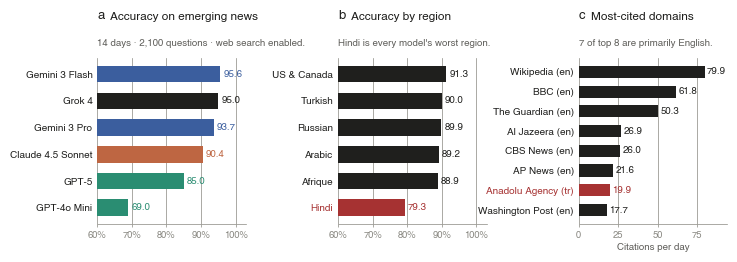

In [16]:
fig = plt.figure(figsize=(7.0, 2.85))
gs  = fig.add_gridspec(1, 3,
                       left=0.085, right=0.985, top=0.75, bottom=0.17,
                       wspace=0.62)
draw_accuracy_panel(fig.add_subplot(gs[0, 0]))
draw_region_panel  (fig.add_subplot(gs[0, 1]))
draw_domains_panel (fig.add_subplot(gs[0, 2]))

savefig(fig, "splash_figure")
plt.show()

## Additional figures (bar charts + global top-10)

The three cells below render the bar charts and the top-domains figure
(`fig_model_accuracy_bar`, `fig_region_accuracy_bar`, `fig_top_domains_global`).
They use the same canonical inputs as the tables above, so the figures and
tables stay in sync by construction.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_model_accuracy_bar


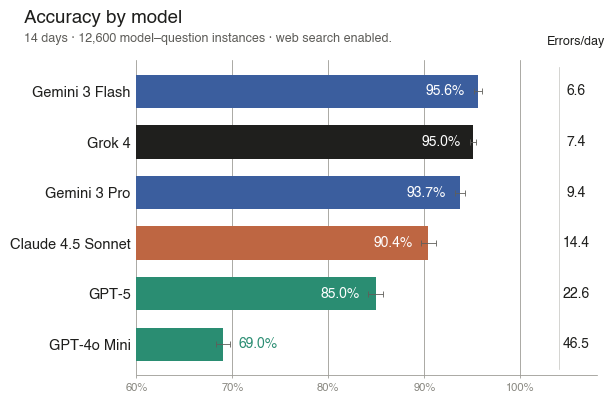

In [17]:
# ── Figure: model accuracy bar ────────────────────────────────────────
# Horizontal bar chart of overall model accuracy with a right-margin
# Errors/Day column. Bar values come straight from `table_model` above.
def plot_model_accuracy_bar():
    df = table_model.sort_values("Acc. (%)", ascending=False)
    n = len(df)
    y = list(range(n))[::-1]
    accs = df["Acc. (%)"].tolist()
    errs = df["Errors/Day"].tolist()
    ses = (df["± SD"] / np.sqrt(14)).tolist()
    colors = [PAL["provider"][PROVIDERS[m]] for m in df.index]

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    ax.barh(y, accs, height=0.66, color=colors, edgecolor="none", zorder=2)

    ax.set_xlim(60, 108)
    ax.set_xticks([60, 70, 80, 90, 100])
    ax.set_xticklabels([f"{x}%" for x in [60, 70, 80, 90, 100]], fontsize=8)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=1)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])

    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=10.5,
                       color=PAL["text_main"], fontweight=600)
    ax.tick_params(axis="y", length=0, pad=4)

    for yi, acc, se, c in zip(y, accs, ses, colors):
        ax.errorbar(acc, yi, xerr=se, yerr=None, fmt="none",
                    ecolor=PAL["text_mid"], capsize=2.5, capthick=0.6,
                    elinewidth=0.6, zorder=3)
        if acc >= 75:
            ax.text(acc - se - 0.9, yi, f"{acc:.1f}%", va="center", ha="right",
                    fontsize=10, color="white", fontweight="bold", zorder=4)
        else:
            ax.text(acc + se + 0.9, yi, f"{acc:.1f}%", va="center", ha="left",
                    fontsize=10, color=c, fontweight="bold", zorder=4)

    ax.axvline(x=104, color=PAL["text_muted"], linewidth=0.5,
               alpha=0.5, ymin=0.02, ymax=0.98)
    ax.text(105.8, n - 0.15, "Errors/day", ha="center", va="bottom",
            fontsize=9.0, fontweight="bold", color=PAL["text_main"])
    for yi, e in zip(y, errs):
        ax.text(105.8, yi, f"{e:.1f}", ha="center", va="center",
                fontsize=10.0, color=PAL["text_main"])

    fig.text(0.025, 0.97, "Accuracy by model",
             fontsize=13.5, fontweight="bold",
             color=PAL["text_main"], va="top")
    fig.text(0.025, 0.915,
             "14 days \u00b7 12,600 model\u2013question instances \u00b7 web search enabled.",
             fontsize=9.0, color=PAL["text_mid"], va="top")
    fig.subplots_adjust(left=0.20, right=0.92, top=0.85, bottom=0.10)

    savefig(fig, "fig_model_accuracy_bar")
    plt.show()

plot_model_accuracy_bar()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_region_accuracy_bar


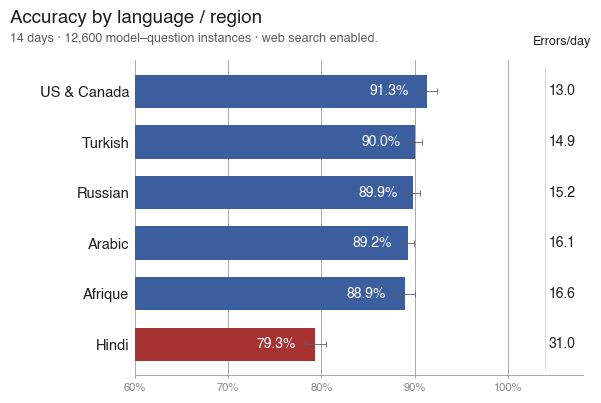

In [18]:
# ── Figure: region accuracy bar ───────────────────────────────────────
# Same idiom as fig_model_accuracy_bar above; Hindi is highlighted in
# PAL["accent"] (red) since every model bottoms out there.
def plot_region_accuracy_bar():
    df = table_region.sort_values("Acc. (%)", ascending=False)
    n = len(df)
    y = list(range(n))[::-1]
    accs = df["Acc. (%)"].tolist()
    errs = df["Errors/Day"].tolist()
    ses = (df["± SD"] / np.sqrt(14)).tolist()
    colors = [PAL["accent"] if r == "Hindi" else PAL["provider"]["google"]
              for r in df.index]

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    ax.barh(y, accs, height=0.66, color=colors, edgecolor="none", zorder=2)

    ax.set_xlim(60, 108)
    ax.set_xticks([60, 70, 80, 90, 100])
    ax.set_xticklabels([f"{x}%" for x in [60, 70, 80, 90, 100]], fontsize=8)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=1)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])

    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=10.5,
                       color=PAL["text_main"], fontweight=600)
    ax.tick_params(axis="y", length=0, pad=4)

    for yi, acc, se, c in zip(y, accs, ses, colors):
        ax.errorbar(acc, yi, xerr=se, yerr=None, fmt="none",
                    ecolor=PAL["text_mid"], capsize=2.5, capthick=0.6,
                    elinewidth=0.6, zorder=3)
        if acc >= 75:
            ax.text(acc - se - 0.9, yi, f"{acc:.1f}%", va="center", ha="right",
                    fontsize=10, color="white", fontweight="bold", zorder=4)
        else:
            ax.text(acc + se + 0.9, yi, f"{acc:.1f}%", va="center", ha="left",
                    fontsize=10, color=c, fontweight="bold", zorder=4)

    ax.axvline(x=104, color=PAL["text_muted"], linewidth=0.5,
               alpha=0.5, ymin=0.02, ymax=0.98)
    ax.text(105.8, n - 0.15, "Errors/day", ha="center", va="bottom",
            fontsize=9.0, fontweight="bold", color=PAL["text_main"])
    for yi, e in zip(y, errs):
        ax.text(105.8, yi, f"{e:.1f}", ha="center", va="center",
                fontsize=10.0, color=PAL["text_main"])

    fig.text(0.025, 0.97, "Accuracy by language / region",
             fontsize=13.5, fontweight="bold",
             color=PAL["text_main"], va="top")
    fig.text(0.025, 0.915,
             "14 days \u00b7 12,600 model\u2013question instances \u00b7 web search enabled.",
             fontsize=9.0, color=PAL["text_mid"], va="top")
    fig.subplots_adjust(left=0.22, right=0.92, top=0.85, bottom=0.10)

    savefig(fig, "fig_region_accuracy_bar")
    plt.show()

plot_region_accuracy_bar()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_top_domains_global


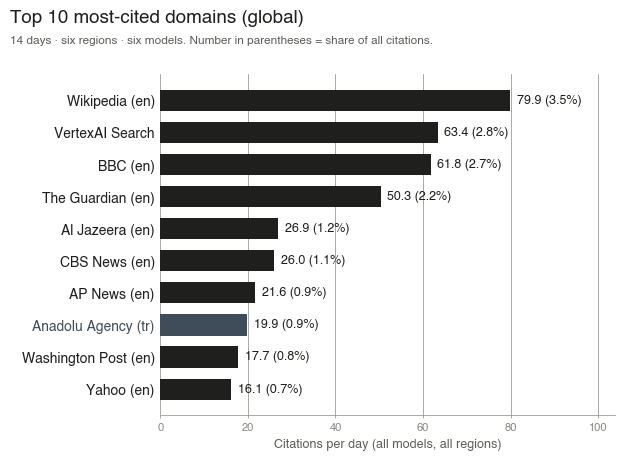

In [19]:
# ── Figure: top-10 cited domains globally ─────────────────────────────
# Horizontal bars of cites/day; non-English-primary outlets shaded slate-blue.
def plot_top_domains_global(top_n=10):
    # Friendly display labels for the canonical domain strings.
    DISPLAY = {
        # Lowercase short-form language tags, matching SPLASH_DOMAINS and DOMAIN_LABELS.
        # VertexAI Search is an opaque API redirect (not a primary news source) and is
        # left untagged.
        "en.wikipedia.org":              "Wikipedia (en)",
        "vertexaisearch.cloud.google.com":"VertexAI Search",
        "bbc.com":                       "BBC (en)",
        "theguardian.com":               "The Guardian (en)",
        "aljazeera.com":                 "Al Jazeera (en)",
        "cbsnews.com":                   "CBS News (en)",
        "apnews.com":                    "AP News (en)",
        "aa.com.tr":                     "Anadolu Agency (tr)",
        "washingtonpost.com":            "Washington Post (en)",
        "yahoo.com":                     "Yahoo (en)",
        "aljazeera.net":                 "Al Jazeera (ar)",
        "reuters.com":                   "Reuters (en)",
    }
    # Domains whose primary language is NOT English (Anglophone-pivot story).
    NON_ENGLISH = {"aa.com.tr", "aljazeera.net"}  # aljazeera.com is English (.net is the Arabic flagship)

    df_top = top_domains.head(top_n).reset_index()
    df_top.columns = ["domain", "cites_per_day", "share_pct"]
    labels = [DISPLAY.get(d, d) for d in df_top["domain"]]
    cps    = df_top["cites_per_day"].tolist()
    shares = df_top["share_pct"].tolist()
    colors = [PAL["accent_soft"] if d in NON_ENGLISH else PAL["primary"]
              for d in df_top["domain"]]

    n = len(df_top)
    y = list(range(n))[::-1]

    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.barh(y, cps, height=0.66, color=colors, edgecolor="none", zorder=2)

    for yi, v, share in zip(y, cps, shares):
        ax.text(v + 1.5, yi, f"{v:.1f} ({share:.1f}%)",
                va="center", ha="left",
                fontsize=9.0, color=PAL["text_main"])

    ax.set_xlim(0, max(cps) * 1.3)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels([str(x) for x in [0, 20, 40, 60, 80, 100]], fontsize=8)
    ax.set_xlabel("Citations per day (all models, all regions)",
                  fontsize=9.0, color=PAL["text_mid"], labelpad=4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=1)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10.0,
                       color=PAL["text_main"], fontweight=600)
    ax.tick_params(axis="y", length=0, pad=4)
    # Color non-English-primary tick labels in slate-blue too.
    for tl, d in zip(ax.get_yticklabels(), df_top["domain"]):
        if d in NON_ENGLISH:
            tl.set_color(PAL["accent_soft"])

    fig.text(0.025, 0.975, "Top 10 most-cited domains (global)",
             fontsize=13.5, fontweight="bold",
             color=PAL["text_main"], va="top")
    fig.text(0.025, 0.92,
             "14 days \u00b7 six regions \u00b7 six models. "
             "Number in parentheses = share of all citations.",
             fontsize=8.5, color=PAL["text_mid"], va="top")
    fig.subplots_adjust(left=0.26, right=0.97, top=0.84, bottom=0.13)

    savefig(fig, "fig_top_domains_global")
    plt.show()

plot_top_domains_global()


## 4&nbsp;&middot;&nbsp;Citation behavior

We compute three citation-behavior results:

* per-model **citation rate** and **citation density**;
* per-model **BBC source citation rate**;
* the **top-cited domains by region** (the dumbbell figure).


In [20]:
df["has_url"] = df["n_urls"] > 0
df["has_bbc"] = df["domains"].apply(lambda ds: "bbc.com" in ds)

cite_rates = pd.DataFrame({
    "Citation rate (%)": (df.groupby("model")["has_url"].mean() * 100),
    "Density (URLs/resp.)": df.groupby("model")["n_urls"].mean(),
    "BBC citation rate (%)": (df.groupby("model")["has_bbc"].mean() * 100),
}).reindex(MODEL_NAMES)

print("Table  ·  Citation behavior by model")
display(cite_rates.round(2))

Table  ·  Citation behavior by model


,Citation rate (%),Density (URLs/resp.),BBC citation rate (%)
model,,,
Gemini 3 Flash,98.33,4.02,6.90
Gemini 3 Pro,84.71,2.64,4.10
Grok 4,88.10,2.59,28.52
Claude 4.5 Sonnet,96.24,3.16,0.00
GPT-5,97.76,1.61,0.19
GPT-4o Mini,86.19,1.27,0.05


### 4.1 BBC source citation rate

A horizontal bar chart in the same provenance palette as the splash.
The rate is computed at the response level: a response is counted if any
cited URL belongs to a BBC domain (`bbc.com` or `bbc.co.uk`, normalized to
`bbc.com`).

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_bbc_citation_rates


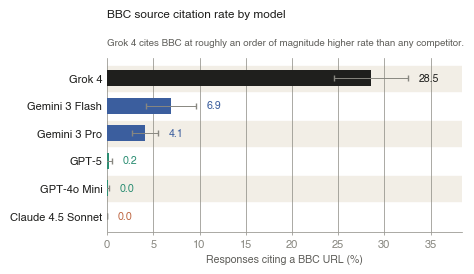

In [21]:
def plot_bbc_citation(rates):
    rates = rates.sort_values(ascending=False)
    models = list(rates.index); vals = rates.values

    sd = (df.assign(has_bbc=df["has_bbc"].astype(int))
            .groupby(["model", "day"])["has_bbc"].mean()
            .groupby(level=0).std() * 100)
    sd = sd.reindex(models).values
    colors = [PAL["provider"][PROVIDERS[m]] for m in models]

    fig, ax = plt.subplots(figsize=(5.0, 3.0))
    y = np.arange(len(models))[::-1]
    for yi in y[::2]:
        ax.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)

    ax.barh(y, vals, height=0.58, color=colors, edgecolor="none", zorder=2)
    ax.errorbar(vals, y, xerr=sd, fmt="none", ecolor=PAL["text_muted"],
                elinewidth=0.7, capsize=2.5, zorder=3)

    # Labels sit clearly past each row's error-bar cap.
    label_pad = max(vals) * 0.04
    for yi, v, c, sd_i in zip(y, vals, colors, sd):
        ax.text(v + sd_i + label_pad, yi, f"{v:.1f}",
                va="center", ha="left",
                fontsize=7.6, fontweight="bold", color=c)

    ax.set_yticks(y); ax.set_yticklabels(models, fontsize=8, color=PAL["text_main"])
    ax.set_xlim(0, max(vals + sd) * 1.18)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True); clean_spines(ax)
    ax.set_xlabel("Responses citing a BBC URL (%)",
                  fontsize=7.6, color=PAL["text_mid"], labelpad=3)
    panel_header(ax, "", "BBC source citation rate by model",
                 "Grok 4 cites BBC at roughly an order of magnitude higher rate than any competitor.")
    fig.subplots_adjust(left=0.28, right=0.99, top=0.78, bottom=0.20)
    savefig(fig, "fig_bbc_citation_rates")
    plt.show()

plot_bbc_citation(cite_rates["BBC citation rate (%)"])

### 4.2 Citation rate and density

A two-panel companion figure that pairs the citation *rate* (proportion of
responses with any URL) with citation *density* (mean URLs per response).
This replaces the prose in Section&nbsp;3.1.1 with a single visual.

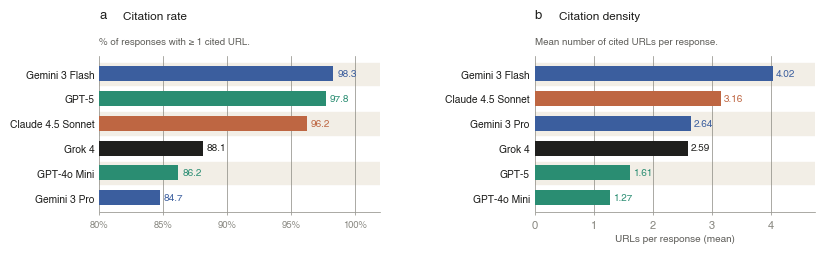

In [22]:
def plot_citation_rate_and_density(rates_df):
    fig = plt.figure(figsize=(8.0, 2.9))
    gs  = fig.add_gridspec(1, 2, left=0.09, right=0.985,
                           top=0.74, bottom=0.20, wspace=0.55)

    # Panel A — citation rate
    axA = fig.add_subplot(gs[0, 0])
    s = rates_df["Citation rate (%)"].sort_values(ascending=False)
    models = list(s.index); vals = s.values
    y = np.arange(len(models))[::-1]
    colors = [PAL["provider"][PROVIDERS[m]] for m in models]
    for yi in y[::2]:
        axA.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)
    axA.barh(y, vals, height=0.60, color=colors, edgecolor="none", zorder=2)
    for yi, v, c in zip(y, vals, colors):
        axA.text(v + 0.3, yi, f"{v:.1f}", va="center", ha="left",
                 fontsize=7.2, fontweight="bold", color=c)
    axA.set_yticks(y); axA.set_yticklabels(models, fontsize=7.4)
    axA.set_xlim(80, 102); axA.set_xticks([80, 85, 90, 95, 100])
    axA.set_xticklabels([f"{x}%" for x in [80, 85, 90, 95, 100]], fontsize=6.8)
    axA.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    axA.set_axisbelow(True); clean_spines(axA)
    panel_header(axA, "a", "Citation rate", "% of responses with ≥ 1 cited URL.")

    # Panel B — citation density
    axB = fig.add_subplot(gs[0, 1])
    s = rates_df["Density (URLs/resp.)"].sort_values(ascending=False)
    models = list(s.index); vals = s.values
    y = np.arange(len(models))[::-1]
    colors = [PAL["provider"][PROVIDERS[m]] for m in models]
    for yi in y[::2]:
        axB.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)
    axB.barh(y, vals, height=0.60, color=colors, edgecolor="none", zorder=2)
    for yi, v, c in zip(y, vals, colors):
        axB.text(v + 0.05, yi, f"{v:.2f}", va="center", ha="left",
                 fontsize=7.2, fontweight="bold", color=c)
    axB.set_yticks(y); axB.set_yticklabels(models, fontsize=7.4)
    axB.set_xlim(0, max(vals) * 1.18)
    axB.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    axB.set_axisbelow(True); clean_spines(axB)
    axB.set_xlabel("URLs per response (mean)",
                   fontsize=7.2, color=PAL["text_mid"], labelpad=3)
    panel_header(axB, "b", "Citation density", "Mean number of cited URLs per response.")

    # orphan figure (not used in manuscript) — disabled by cleanup
    # savefig(fig, "fig_citation_rate_density")
    plt.show()

plot_citation_rate_and_density(cite_rates)

### 4.3 Top cited domains by region

The dumbbell figure shows, for each region, the top&nbsp;8 cited domains and
the cross-model spread within them. The horizontal span of each dumbbell is
the model-specific variance in which outlets get cited.


In [23]:
# ------------------------------------------------------------------
# Domain → human-readable label registry (language-aware).
#
# The dumbbell + small-multiples figures need legible labels that flag
# language-specific variants (Wikipedia (en) vs (hi); Al Jazeera (en) vs
# (ar); etc.). We keep this as a single source of truth so any figure
# that displays domains uses the same names.
#
# Notes on aggregation:
#   * `bbc.com` is the *normalized* domain; under the hood we collapse
#     `bbc.co.uk` and every `*.bbc.com` subdomain into this single bucket
#     (see `normalize_domain`). Reported as "BBC" with no language tag
#     because BBC services share editorial scope across both hosts.
#   * `vertexaisearch.cloud.google.com` is Google's grounding-redirect
#     URL. The destination is opaque to the API, so we keep it as a
#     single accountable bucket and label it "VertexAI redirect" — it is
#     **not** a primary news source and is shown only for completeness.
#   * Wikipedia language editions (en, fr, hi, ar, ru, tr, …) are kept
#     separate. Aggregating them would obscure the central finding that
#     models cite English Wikipedia even when answering non-English
#     questions.
# ------------------------------------------------------------------
DOMAIN_LABELS = {
    # ----- BBC (merged: bbc.com + bbc.co.uk) -----
    "bbc.com":               ("BBC",              ""),

    # ----- Wikipedia language editions -----
    "en.wikipedia.org":      ("Wikipedia",        "en"),
    "fr.wikipedia.org":      ("Wikipedia",        "fr"),
    "ar.wikipedia.org":      ("Wikipedia",        "ar"),
    "ru.wikipedia.org":      ("Wikipedia",        "ru"),
    "tr.wikipedia.org":      ("Wikipedia",        "tr"),
    "hi.wikipedia.org":      ("Wikipedia",        "hi"),
    "es.wikipedia.org":      ("Wikipedia",        "es"),
    "de.wikipedia.org":      ("Wikipedia",        "de"),
    "pt.wikipedia.org":      ("Wikipedia",        "pt"),
    "simple.wikipedia.org":  ("Wikipedia",        "simple"),
    "wikipedia.org":         ("Wikipedia",        ""),

    # ----- Al Jazeera (separate language brands) -----
    "aljazeera.com":         ("Al Jazeera",       "en"),
    "aljazeera.net":         ("Al Jazeera",       "ar"),
    "studies.aljazeera.net": ("Al Jazeera Studies","ar"),

    # ----- VertexAI grounding redirect (opaque) -----
    "vertexaisearch.cloud.google.com": ("VertexAI (Gemini)", ""),

    # ----- US & Canada / English -----
    "cbsnews.com":           ("CBS News",         "en"),
    "theguardian.com":       ("The Guardian",     "en"),
    "apnews.com":            ("AP News",          "en"),
    "washingtonpost.com":    ("Washington Post",  "en"),
    "yahoo.com":             ("Yahoo News",       "en"),
    "pbs.org":               ("PBS",              "en"),
    "time.com":              ("Time",             "en"),
    "cbc.ca":                ("CBC",              "en"),
    "nbcnews.com":           ("NBC News",         "en"),
    "cnn.com":               ("CNN",              "en"),
    "reuters.com":           ("Reuters",          "en"),
    "axios.com":             ("Axios",            "en"),
    "abcnews.go.com":        ("ABC News",         "en"),
    "nytimes.com":           ("New York Times",   "en"),

    # ----- Africa / French -----
    "dakaractu.com":         ("Dakar Actu",       "fr"),
    "senenews.com":          ("SeneNews",         "fr"),
    "jeuneafrique.com":      ("Jeune Afrique",    "fr"),
    "africanews.com":        ("Africanews",       "en"),
    "france24.com":          ("France 24",        "fr"),
    "rfi.fr":                ("RFI",              "fr"),
    "lemonde.fr":            ("Le Monde",         "fr"),
    "lefigaro.fr":           ("Le Figaro",        "fr"),
    "tv5monde.com":          ("TV5MONDE",         "fr"),

    # ----- Arabic -----
    "almasryalyoum.com":     ("Al-Masry Al-Youm", "ar"),
    "youm7.com":             ("Youm7",            "ar"),
    "alarabiya.net":         ("Al Arabiya",       "ar"),
    "elwatannews.com":       ("Al Watan News",    "ar"),
    "asharq.com":            ("Asharq",           "ar"),
    "skynewsarabia.com":     ("Sky News Arabia",  "ar"),
    "aawsat.com":            ("Asharq Al-Awsat",  "ar"),
    "timesofisrael.com":     ("Times of Israel",  "en"),

    # ----- Hindi / India -----
    "hindustantimes.com":           ("Hindustan Times",     "en"),
    "aajtak.in":                    ("Aaj Tak",             "hi"),
    "indiatoday.in":                ("India Today",         "en"),
    "timesofindia.indiatimes.com":  ("Times of India",      "en"),
    "thehindu.com":                 ("The Hindu",           "en"),
    "economictimes.indiatimes.com": ("Economic Times",      "en"),
    "indianexpress.com":            ("Indian Express",      "en"),
    "ndtv.com":                     ("NDTV",                "en"),
    "news18.com":                   ("News18",              "en"),
    "pib.gov.in":                   ("PIB India",           "en"),
    "icsi.edu":                     ("ICSI",                "en"),
    "iirfranking.com":              ("IIRF Ranking",        "en"),
    "navbharattimes.indiatimes.com":("Navbharat Times",     "hi"),
    "amarujala.com":                ("Amar Ujala",          "hi"),
    "jagran.com":                   ("Dainik Jagran",       "hi"),
    "bhaskar.com":                  ("Dainik Bhaskar",      "hi"),

    # ----- Russian -----
    "rbc.ru":                ("RBC",              "ru"),
    "olympics.com":          ("Olympics.com",     "en"),
    "meduza.io":             ("Meduza",           "ru"),
    "news.zerkalo.io":       ("Zerkalo (Belarus)","ru"),
    "ria.ru":                ("RIA Novosti",      "ru"),
    "tass.com":              ("TASS",             "en"),
    "tass.ru":               ("TASS",             "ru"),
    "kommersant.ru":         ("Kommersant",       "ru"),
    "interfax.ru":           ("Interfax",         "ru"),
    "lenta.ru":              ("Lenta",            "ru"),

    # ----- Turkish -----
    "t24.com.tr":            ("T24",              "tr"),
    "aa.com.tr":             ("Anadolu Agency",   "tr"),
    "cumhuriyet.com.tr":     ("Cumhuriyet",       "tr"),
    "haberler.com":          ("Haberler",         "tr"),
    "hurriyet.com.tr":       ("Hürriyet",         "tr"),
    "gazeteoksijen.com":     ("Gazete Oksijen",   "tr"),
    "medyascope.tv":         ("Medyascope TV",    "tr"),
    "birgun.net":            ("BirGün",           "tr"),
    "sozcu.com.tr":          ("Sözcü",            "tr"),
    "milliyet.com.tr":       ("Milliyet",         "tr"),
    "ntv.com.tr":            ("NTV",              "tr"),
    "haberturk.com":         ("Habertürk",        "tr"),
    "trthaber.com":          ("TRT Haber",        "tr"),
}

# Languages that match the *region* the citation appeared in. We use this
# to color non-region-language sources (the "Anglophone retrieval pivot"
# discussed in §3.1.3) on the small-multiples figure.
REGION_NATIVE_LANG = {
    "US & Canada": {"en"},
    "Afrique":     {"fr"},
    "Arabic":      {"ar"},
    "Hindi":       {"hi"},
    "Russian":     {"ru"},
    "Turkish":     {"tr"},
}

def domain_label(host: str) -> str:
    """Return the publication-grade label for a host.

    Falls back to the bare host (without `www.`) when no entry exists.
    Wikipedia / Al Jazeera variants get a parenthetical language tag.
    """
    base, lang = DOMAIN_LABELS.get(host, (None, None))
    if base is None:
        return host
    return f"{base} ({lang})" if lang else base

def domain_lang(host: str) -> str:
    """Return the language code we associate with `host`, or '' if unknown."""
    _, lang = DOMAIN_LABELS.get(host, ("", ""))
    return lang or ""

def is_native(host: str, region: str) -> bool:
    """True iff `host`'s language matches the region's native language."""
    return domain_lang(host) in REGION_NATIVE_LANG.get(region, set())

In [24]:
def per_region_top_domains(top_n=8):
    """Compute, for each region, the per-model and aggregate cites/day for
    the top-N domains in that region."""
    out = {}
    for region in REGION_NAMES:
        sub = exploded[exploded["region"] == region]
        ranking = (sub.groupby("domains").size() / N_DAYS).sort_values(ascending=False).head(top_n)
        per_model = (sub.groupby(["domains", "model"]).size()
                     .unstack("model").fillna(0) / N_DAYS)
        per_model = per_model.reindex(ranking.index)[MODEL_NAMES]
        out[region] = (ranking, per_model)
    return out
top_per_region = per_region_top_domains()

# Per-region top-N domains computed once; cited by the figures below.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_domain_dumbbell


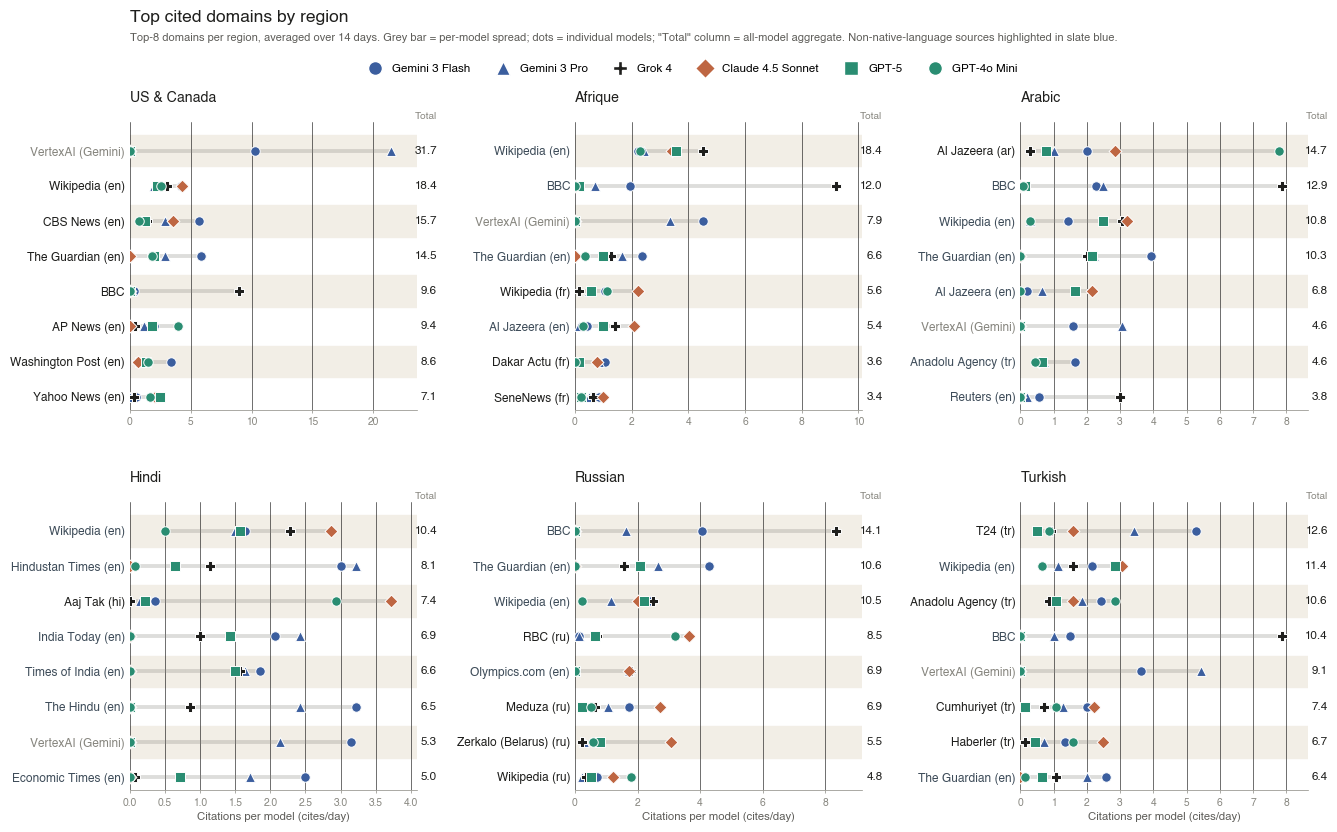

In [25]:
def plot_domain_dumbbell(top_n=8):
    """Small-multiples dumbbell: spread bar + per-model shape markers
    + right-aligned \"Total\" column outside the data region."""
    fig = plt.figure(figsize=(12.6, 8.6))
    gs = fig.add_gridspec(2, 3, left=0.055, right=0.99,
                          top=0.855, bottom=0.078,
                          wspace=0.55, hspace=0.32)
    axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]

    import matplotlib.transforms as mtrans
    for ax, region in zip(axes, REGION_NAMES):
        ranking, per_model = top_per_region[region]
        hosts = list(ranking.index)
        agg   = ranking.values
        y     = np.arange(len(hosts))[::-1]

        mins = per_model.min(axis=1).values
        maxs = per_model.max(axis=1).values
        x_top = max(maxs) * 1.10

        for yi in y[::2]:
            ax.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)

        for yi, lo, hi in zip(y, mins, maxs):
            ax.plot([lo, hi], [yi, yi], color=PAL["text_muted"],
                    linewidth=2.8, alpha=0.28,
                    solid_capstyle="round", zorder=1)

        for m in per_model.columns:
            style = MODEL_STYLE[m]
            ax.scatter(per_model[m].values, y,
                       marker=style["marker"],
                       s=style["size"] * 1.95,
                       color=style["color"],
                       edgecolors="white", linewidths=0.7,
                       label=m if region == REGION_NAMES[0] else None,
                       zorder=3)

        labels = [domain_label(h) for h in hosts]
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8.6, color=PAL["text_main"])
        for tl, h in zip(ax.get_yticklabels(), hosts):
            if h == "vertexaisearch.cloud.google.com":
                tl.set_color(PAL["text_muted"]); tl.set_fontstyle("italic")
            elif region != "US & Canada" and not is_native(h, region):
                tl.set_color(PAL["accent_soft"])

        ax.set_xlim(0, x_top)
        ax.xaxis.grid(True, color=(0, 0, 0, 0.050), linewidth=0.4, zorder=0)
        ax.set_axisbelow(True); clean_spines(ax)
        ax.tick_params(axis="x", labelsize=7.4)

        trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
        ax.text(1.07, len(hosts) - 0.15, "Total", transform=trans,
                ha="right", va="bottom", fontsize=7.2,
                color=PAL["text_muted"], fontweight="bold")
        for yi, v in zip(y, agg):
            ax.text(1.07, yi, f"{v:.1f}", transform=trans,
                    ha="right", va="center", fontsize=8.4,
                    fontweight="bold", color=PAL["text_main"])

        ax.text(0.0, 1.06, region, transform=ax.transAxes,
                fontsize=10.2, fontweight="bold",
                color=PAL["text_main"], ha="left", va="bottom")

    for ax in axes[3:]:
        ax.set_xlabel("Citations per model (cites/day)",
                      fontsize=8.2, color=PAL["text_mid"], labelpad=3)

    legend_handles = [
        plt.Line2D([0], [0],
                   marker=MODEL_STYLE[m]["marker"],
                   color="none",
                   markerfacecolor=MODEL_STYLE[m]["color"],
                   markeredgecolor="white",
                   markersize=10,
                   label=m)
        for m in MODEL_NAMES
    ]
    fig.legend(handles=legend_handles,
               loc="upper center",
               bbox_to_anchor=(0.5, 0.935),
               ncol=len(legend_handles), frameon=False, fontsize=8.4,
               handletextpad=0.45, columnspacing=1.8)

    fig.text(0.055, 0.985, "Top cited domains by region",
             fontsize=12.5, fontweight="bold",
             color=PAL["text_main"], ha="left", va="top")
    fig.text(0.055, 0.958,
             f"Top-{top_n} domains per region, averaged over 14 days. "
             f"Grey bar = per-model spread; dots = individual models; "
             f"\"Total\" column = all-model aggregate. "
             f"Non-native-language sources highlighted in slate blue.",
             fontsize=8.0, color=PAL["text_mid"], ha="left", va="top")

    savefig(fig, "fig_domain_dumbbell")
    plt.show()

plot_domain_dumbbell()

### 4.4 Top cited domains by region — small-multiples view

A complementary view of the dumbbell figure: per-region top-8 domains,
aggregated across all six models. Sources whose primary language differs
from the regional service appear in red; the **VertexAI redirect** row is
de-emphasized in italics because it is an opaque grounding URL rather
than a primary news source. Wikipedia language editions are rendered as
"Wikipedia (en)", "Wikipedia (fr)", etc., and treated as separate
domains throughout — collapsing them would obscure the central English-
dominance finding.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_top_domains_by_region


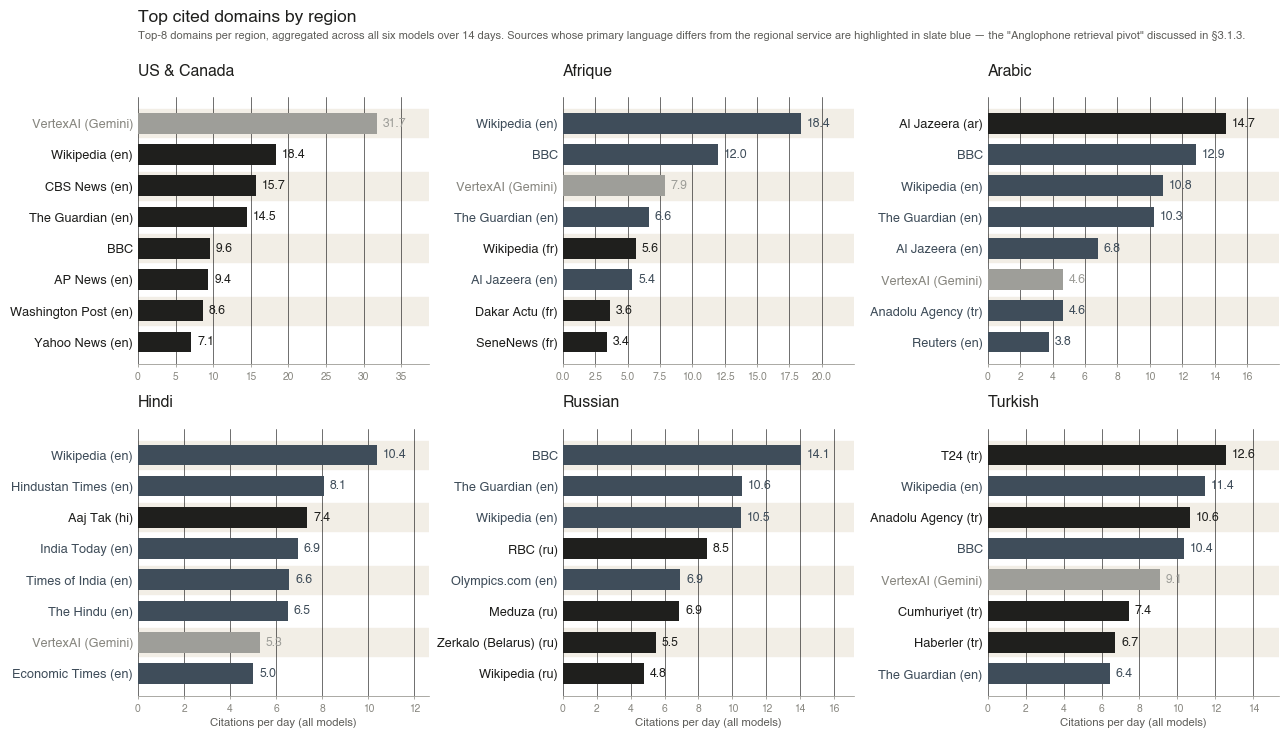

In [26]:
def plot_top_domains_by_region(top_n=8):
    """Small-multiples bar chart: top-N cited domains per region."""
    fig = plt.figure(figsize=(12.2, 7.6))
    gs = fig.add_gridspec(2, 3, left=0.055, right=0.99,
                          top=0.87, bottom=0.082,
                          wspace=0.46, hspace=0.24)
    axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]

    for ax, region in zip(axes, REGION_NAMES):
        sub = exploded[exploded["region"] == region]
        ranking = (sub.groupby("domains").size() / N_DAYS
                   ).sort_values(ascending=False).head(top_n)
        hosts = list(ranking.index); vals = ranking.values
        y = np.arange(len(hosts))[::-1]

        def bar_color(h):
            if h == "vertexaisearch.cloud.google.com":
                return PAL["secondary"]
            if region == "US & Canada":
                return PAL["primary"]
            return PAL["primary"] if is_native(h, region) else PAL["accent_soft"]
        colors = [bar_color(h) for h in hosts]

        for yi in y[::2]:
            ax.axhspan(yi - 0.45, yi + 0.45, color=PAL["stripe"], zorder=0)
        ax.barh(y, vals, height=0.66, color=colors, edgecolor="none", zorder=2)
        for yi, v, c in zip(y, vals, colors):
            ax.text(v + max(vals) * 0.025, yi, f"{v:.1f}",
                    va="center", ha="left", fontsize=8.8,
                    fontweight="bold", color=c)

        labels = [domain_label(h) for h in hosts]
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=9.2, color=PAL["text_main"], fontweight=600)
        for tl, h in zip(ax.get_yticklabels(), hosts):
            if h == "vertexaisearch.cloud.google.com":
                tl.set_color(PAL["text_muted"]); tl.set_fontstyle("italic")
            elif region != "US & Canada" and not is_native(h, region):
                tl.set_color(PAL["accent_soft"])

        ax.set_xlim(0, max(vals) * 1.22)
        ax.xaxis.grid(True, color=(0, 0, 0, 0.055), linewidth=0.4, zorder=0)
        ax.set_axisbelow(True); clean_spines(ax)
        ax.tick_params(axis="x", labelsize=7.4)
        ax.text(0.0, 1.07, region, transform=ax.transAxes,
                fontsize=11.4, fontweight="bold",
                color=PAL["text_main"], ha="left", va="bottom")

    for ax in axes[3:]:
        ax.set_xlabel("Citations per day (all models)",
                      fontsize=8.2, color=PAL["text_mid"], labelpad=3)

    fig.text(0.055, 0.985, "Top cited domains by region",
             fontsize=12.5, fontweight="bold",
             color=PAL["text_main"], ha="left", va="top")
    fig.text(0.055, 0.958,
             f"Top-{top_n} domains per region, aggregated across all six "
             f"models over 14 days. Sources whose primary language differs "
             f"from the regional service are highlighted in slate blue — "
             f"the \"Anglophone retrieval pivot\" discussed in §3.1.3.",
             fontsize=8.0, color=PAL["text_mid"], ha="left", va="top")

    savefig(fig, "fig_top_domains_by_region")
    plt.show()

plot_top_domains_by_region()

## 5&nbsp;&middot;&nbsp;Web-search ablation

We compute the per-model accuracy with web search on (the canonical run) and
with web search off (the baseline run), restricted to US&nbsp;\&&nbsp;Canada,
and surface the per-model gap.


In [27]:
df_baseline = pd.DataFrame(build_records(
    [m for m, _ in BASELINE_MODELS],
    region_subset=["uscanada"],
    baseline=True,
))
print(f"baseline rows: {len(df_baseline):,}")
display(df_baseline.head(2))

baseline rows: 1,400


,region_dir,region,model_dir,model,provider,baseline,day,q_idx,correct,predicted,is_correct,n_urls,n_unique_domains,domains,urls,source_url
0,uscanada,US & Canada,gemini-3-pro-preview-baseline,Gemini 3 Pro,,True,february_9,0,A,B,False,2,2,"[thegatewaypundit.com, dailymail.co.uk]",[https://www.thegatewaypundit.com/2025/02/brea...,https://www.bbc.com/news/articles/cvgv5yre39zo
1,uscanada,US & Canada,gemini-3-pro-preview-baseline,Gemini 3 Pro,,True,february_9,1,B,NaN,False,0,0,[],[],https://www.bbc.com/news/articles/c5y4dyp0765o


In [28]:
# Search-on accuracy on US & Canada, restricted to the four models that have a baseline counterpart
search_models = [n for _, n in BASELINE_MODELS]
search_on = (df[(df["region"] == "US & Canada") & (df["model"].isin(search_models))]
             .groupby("model")["is_correct"].mean() * 100)
search_off = df_baseline.groupby("model")["is_correct"].mean() * 100

ablation = pd.DataFrame({
    "Search ON (%)":  search_on,
    "Search OFF (%)": search_off,
})
ablation["Δ (pp)"] = ablation["Search ON (%)"] - ablation["Search OFF (%)"]
ablation = ablation.reindex(search_models)

print("Web-search ablation · US & Canada · 14-day average")
display(ablation.round(1))

Web-search ablation · US & Canada · 14-day average


,Search ON (%),Search OFF (%),Δ (pp)
model,,,
Gemini 3 Pro,96.0,60.6,35.4
Grok 4,96.9,51.1,45.7
Claude 4.5 Sonnet,95.7,57.7,38.0
GPT-5,88.6,58.0,30.6


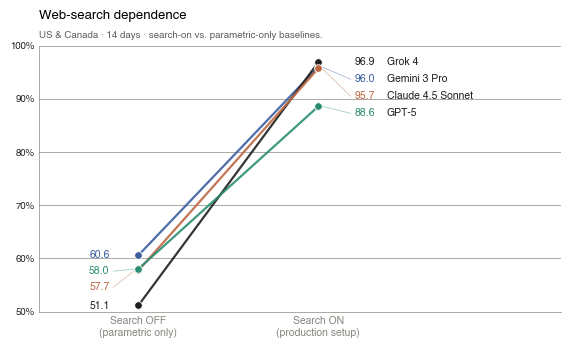

In [29]:
def plot_ablation_slope(ablation):
    fig, ax = plt.subplots(figsize=(6.0, 3.8))
    x_off, x_on = 0.0, 1.0

    def stagger(vals, min_gap=1.8):
        order = np.argsort(-np.array(vals))
        out = list(vals)
        for idx in range(1, len(order)):
            i, j = order[idx-1], order[idx]
            if out[i] - out[j] < min_gap:
                out[j] = out[i] - min_gap
        return out

    off_raw = [ablation.loc[m, "Search OFF (%)"] for m in ablation.index]
    on_raw  = [ablation.loc[m, "Search ON (%)"]  for m in ablation.index]
    off_y   = stagger(off_raw, min_gap=3.0)
    on_y    = stagger(on_raw,  min_gap=3.2)

    for i, model in enumerate(ablation.index):
        off, on = off_raw[i], on_raw[i]
        oy, ny  = off_y[i], on_y[i]
        c = PAL["provider"][PROVIDERS[model]]
        ax.plot([x_off, x_on], [off, on], "-",
                color=c, linewidth=1.6, alpha=0.9, zorder=2)
        ax.scatter([x_off, x_on], [off, on], s=30,
                   color=c, edgecolors="white", linewidths=0.6, zorder=3)
        if abs(oy - off) > 0.05:
            ax.plot([x_off - 0.02, x_off - 0.14], [off, oy],
                    color=c, linewidth=0.5, alpha=0.5, zorder=1)
        ax.text(x_off - 0.16, oy, f"{off:.1f}",
                ha="right", va="center", color=c, fontsize=7.5, fontweight="bold")

        if abs(ny - on) > 0.05:
            ax.plot([x_on + 0.02, x_on + 0.18], [on, ny],
                    color=c, linewidth=0.5, alpha=0.5, zorder=1)
        ax.text(x_on + 0.20, ny, f"{on:.1f}",
                ha="left", va="center", color=c, fontsize=7.5, fontweight="bold")
        ax.text(x_on + 0.38, ny, model,
                ha="left", va="center", color=PAL["text_main"], fontsize=7.5)

    ax.set_xticks([x_off, x_on])
    ax.set_xticklabels(["Search OFF\n(parametric only)",
                        "Search ON\n(production setup)"], fontsize=7.5)
    ax.set_xlim(-0.55, 2.35); ax.set_ylim(50, 100)
    ax.set_yticks([50, 60, 70, 80, 90, 100])
    ax.set_yticklabels([f"{y}%" for y in [50, 60, 70, 80, 90, 100]], fontsize=7)
    ax.yaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"]); ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_color(PAL["text_muted"]);   ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(axis="x", length=0); ax.tick_params(axis="y", length=0)

    ax.text(0.0, 1.10, "Web-search dependence",
            transform=ax.transAxes, fontsize=9.5, fontweight="bold")
    ax.text(0.0, 1.03,
            "US & Canada · 14 days · search-on vs. parametric-only baselines.",
            transform=ax.transAxes, fontsize=7, color=PAL["text_mid"])

    fig.subplots_adjust(left=0.12, right=0.99, top=0.86, bottom=0.16)
    # orphan figure (not used in manuscript) — disabled by cleanup
    # savefig(fig, "fig_ablation_slope")
    plt.show()

plot_ablation_slope(ablation)

## 6&nbsp;&middot;&nbsp;Pipeline validation (April&nbsp;6)

The April&nbsp;6 slice is a one-day re-run used to anchor the multiple-choice
numbers against an open-ended free-response (FR) version of the same
questions. The FR responses and judge annotations are released separately, so
we replicate the **MC** half here.


In [30]:
df_april = pd.DataFrame(build_records(
    [m for m, _, _ in MAIN_MODELS],
    days=["april_6"],
))
print(f"April 6 rows: {len(df_april):,}")

mc_acc = (df_april.groupby("model")["is_correct"].mean() * 100).reindex(MODEL_NAMES)
print("\nApril 6 multiple-choice accuracy by model:")
display(mc_acc.round(1).rename("MC accuracy (%)").to_frame())

April 6 rows: 875

April 6 multiple-choice accuracy by model:


,MC accuracy (%)
model,
Gemini 3 Flash,92.7
Gemini 3 Pro,96.8
Grok 4,92.7
Claude 4.5 Sonnet,92.0
GPT-5,81.3
GPT-4o Mini,69.3


## 7&nbsp;&middot;&nbsp;Adversarial robustness

The adversarial-question per-question outputs are shipped under
`ablation/adversarial_questions_results/`; the false-premise detection
annotations remain a separate artifact (manual / LLM-judge labels). The
standard and adversarial accuracy numbers below are computed directly from
the shipped JSONL; only the detection-rate column is hand-coded from the
manuscript. The two adversarial figures below use the
per-model summary numbers reported in the manuscript so the figures can be
regenerated in the same provenance style. To replace those summary numbers
with a fresh re-run, simply rebuild the two `DataFrame`s below from the
adversarial output files (now shipped under `ablation/adversarial_questions_results/`).


In [31]:
# Standard vs. adversarial accuracy on US & Canada (4 days, Feb 19-22).
# Both conditions are derived row-by-row from the shipped JSONL: standard
# from `results/uscanada/{model}/{day}_outputs.jsonl` and adversarial from
# `ablation/adversarial_questions_results/uscanada/{model}/{day}_outputs.jsonl`.
ADV_DAYS = ["february_19", "february_20", "february_21", "february_22"]
ADV_LABEL_TO_DIR = {
    "Grok 4":            "grok-4-0709",
    "Gemini 3 Pro":      "gemini-3-pro-preview",
    "Claude 4.5 Sonnet": "claude-sonnet-4-5",
    "GPT-5":             "gpt-5-search-api",
}

def _acc_over(path_root, label, dir_):
    """Mean per-day accuracy + per-day SD across ADV_DAYS."""
    per_day_correct = []
    per_day_total   = []
    n = 0; ncorrect = 0
    for d in ADV_DAYS:
        fn = path_root / "uscanada" / dir_ / f"{d}_outputs.jsonl"
        if not fn.exists():
            continue
        with open(fn) as f:
            day_rows = [json.loads(l) for l in f if l.strip()]
        day_correct = 0; day_total = 0
        for q_idx, row in enumerate(day_rows):
            pred = extract_answer(row.get("model_output"))
            # Errata only apply to the standard (non-adversarial) pool.
            if path_root == RES:
                gold = gold_with_errata("uscanada", d, q_idx, row.get("correct_answer"))
            else:
                raw = (row.get("correct_answer") or "").strip("() ").upper() or None
                gold = raw[0] if raw and raw[0] in "ABCDEF" else None
            day_total += 1
            if pred is not None and gold is not None and (
                pred in gold if isinstance(gold, frozenset) else pred == gold
            ):
                day_correct += 1
        per_day_correct.append(day_correct)
        per_day_total.append(day_total)
        n += day_total
        ncorrect += day_correct
    return n, ncorrect, per_day_correct, per_day_total

rows = []
for label, dir_ in ADV_LABEL_TO_DIR.items():
    sn, sc, std_pd_correct, std_pd_total = _acc_over(RES, label, dir_)
    an, ac, adv_pd_correct, adv_pd_total = _acc_over(
        ROOT / "ablation" / "adversarial_questions_results", label, dir_)
    rows.append(dict(
        model=label,
        std_n=sn, std_correct=sc,
        adv_n=an, adv_correct=ac,
        std_pd_correct=tuple(std_pd_correct),
        adv_pd_correct=tuple(adv_pd_correct),
    ))

def _se_pp(per_day_correct, per_day_total):
    """Per-day accuracy SD in percentage points (across days)."""
    accs = np.array([100.0*c/t for c,t in zip(per_day_correct, per_day_total) if t])
    return float(accs.std(ddof=0))

adv = pd.DataFrame([
    {
        "Standard errors / 25":   round((r["std_n"] - r["std_correct"]) / max(1, r["std_n"]) * 25, 2),
        "Adversarial errors / 25":round((r["adv_n"] - r["adv_correct"]) / max(1, r["adv_n"]) * 25, 2),
        "Standard acc. (%)":      round(100.0 * r["std_correct"] / r["std_n"], 2) if r["std_n"] else float("nan"),
        "Adv. acc. (%)":          round(100.0 * r["adv_correct"] / r["adv_n"], 2) if r["adv_n"] else float("nan"),
    } for r in rows
], index=[r["model"] for r in rows])
adv["Drop (pp)"] = adv["Standard acc. (%)"] - adv["Adv. acc. (%)"]
display(adv.round(1))

print("Per-day accuracy SD (pp):")
for r in rows:
    print(f"  {r['model']:>20s}: std SD={ _se_pp(r['std_pd_correct'], [25]*len(r['std_pd_correct'])):4.1f}, "
          f"adv SD={_se_pp(r['adv_pd_correct'], [25]*len(r['adv_pd_correct'])):4.1f}")

# Detection rate vs adversarial accuracy. Detection rates are taken from
# the manual / LLM-judge labels reported in the manuscript (the labels are
# not in this repository); the adversarial accuracy column re-uses the
# JSONL-derived `adv` table immediately above so the two figures are
# guaranteed to agree.
DETECTION_RATES = {  # from manuscript Section 4.4.2 (manual labelling)
    "Gemini 3 Pro":      80,
    "Claude 4.5 Sonnet": 78,
    "Grok 4":            59,
    "GPT-5":             36,
}
detection = pd.DataFrame({
    "Detection rate (%)": [DETECTION_RATES[m] for m in DETECTION_RATES],
    "Adv. acc. (%)":      [adv.loc[m, "Adv. acc. (%)"] for m in DETECTION_RATES],
}, index=list(DETECTION_RATES.keys()))
display(detection)


,Standard errors / 25,Adversarial errors / 25,Standard acc. (%),Adv. acc. (%),Drop (pp)
Grok 4,1.0,7.5,96.0,70.0,26.0
Gemini 3 Pro,1.0,11.2,96.0,55.0,41.0
Claude 4.5 Sonnet,2.0,13.5,92.0,46.0,46.0
GPT-5,3.0,20.2,88.0,19.0,69.0


Per-day accuracy SD (pp):
                Grok 4: std SD= 0.0, adv SD= 6.0
          Gemini 3 Pro: std SD= 2.8, adv SD=13.4
     Claude 4.5 Sonnet: std SD= 6.3, adv SD= 4.5
                 GPT-5: std SD= 6.9, adv SD= 5.9


,Detection rate (%),Adv. acc. (%)
Gemini 3 Pro,80,55.0
Claude 4.5 Sonnet,78,46.0
Grok 4,59,70.0
GPT-5,36,19.0


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_standard_vs_adversarial_replicated


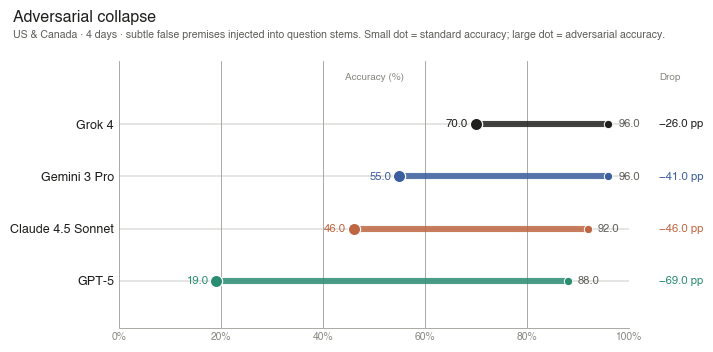

In [32]:
def plot_standard_vs_adversarial(adv):
    adv = adv.sort_values("Adv. acc. (%)", ascending=False)
    fig, ax = plt.subplots(figsize=(7.6, 3.6))

    y = np.arange(len(adv))[::-1]
    for yi, model in zip(y, adv.index):
        std  = adv.loc[model, "Standard acc. (%)"]
        a    = adv.loc[model, "Adv. acc. (%)"]
        drop = std - a
        c    = PAL["provider"][PROVIDERS[model]]

        # Translucent reference track 0→100
        ax.plot([0, 100], [yi, yi], color=PAL["secondary"],
                linewidth=1.1, alpha=0.35, zorder=1)

        # Solid "Adversarial → Standard" bracket
        ax.plot([a, std], [yi, yi], color=c, linewidth=4.4,
                alpha=0.85, solid_capstyle="butt", zorder=2)

        # End-point dots
        ax.scatter([std], [yi], s=36, color=c, edgecolors="white",
                   linewidths=0.7, zorder=3)
        ax.scatter([a],   [yi], s=78, color=c, edgecolors="white",
                   linewidths=0.9, zorder=3, marker="o")

        # Text labels — use axes-coordinate transform for the Drop
        # column so it always sits in the right-hand margin.
        ax.text(std + 2.0, yi, f"{std:.1f}",
                va="center", ha="left",
                fontsize=8.0, color=PAL["text_mid"], fontweight="bold")
        # Place adversarial label to the *left* of its point so it
        # doesn't overlap the connecting bar.
        ax.text(a - 1.5, yi, f"{a:.1f}",
                va="center", ha="right",
                fontsize=8.2, color=c, fontweight="bold")

    # Y-tick model names
    ax.set_yticks(y)
    ax.set_yticklabels(adv.index, fontsize=9, color=PAL["text_main"])
    ax.tick_params(axis="y", length=0, pad=4)

    # Drop column (axes-fraction x so it hugs the right margin)
    import matplotlib.transforms as mtrans
    trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(1.06, len(adv) - 0.2, "Drop",
            transform=trans, ha="left", va="bottom",
            fontsize=7.2, fontweight="bold", color=PAL["text_muted"])
    for yi, model in zip(y, adv.index):
        drop = adv.loc[model, "Standard acc. (%)"] - adv.loc[model, "Adv. acc. (%)"]
        c    = PAL["provider"][PROVIDERS[model]]
        ax.text(1.06, yi, f"−{drop:.1f} pp",
                transform=trans, ha="left", va="center",
                fontsize=8.2, color=c, fontweight="bold")

    # Column labels
    ax.text(50, len(adv) - 0.2, "Accuracy (%)",
            ha="center", va="bottom",
            fontsize=7.2, fontweight="bold", color=PAL["text_muted"])

    ax.set_xlim(0, 100); ax.set_ylim(-0.9, len(adv) + 0.2)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 20, 40, 60, 80, 100]], fontsize=7.4)
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"])
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="x", length=0, pad=3)

    fig.text(0.02, 0.97, "Adversarial collapse",
             fontsize=11.5, fontweight="bold", color=PAL["text_main"])
    fig.text(0.02, 0.925,
             "US & Canada · 4 days · subtle false premises injected into question stems. "
             "Small dot = standard accuracy; large dot = adversarial accuracy.",
             fontsize=7.6, color=PAL["text_mid"])

    fig.subplots_adjust(left=0.16, right=0.83, top=0.86, bottom=0.12)
    savefig(fig, "fig_standard_vs_adversarial_replicated")
    plt.show()

plot_standard_vs_adversarial(adv)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote fig_detection_vs_accuracy_replicated


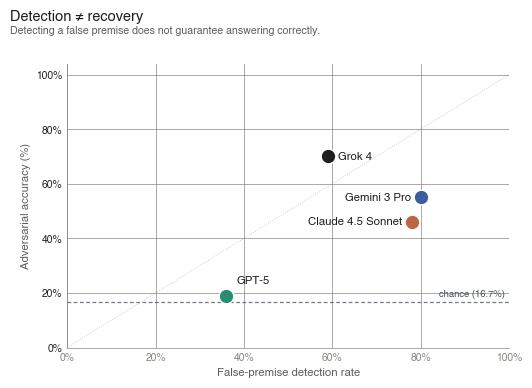

In [33]:
def plot_detection_vs_accuracy(detection):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    # Chance line first (below everything else)
    # Six-option adversarial set: chance = 1/6 ≈ 16.7%
    ax.axhline(100/6, color=PAL["accent_soft"], linewidth=0.9,
               linestyle=(0, (3, 2)), alpha=0.75, zorder=1)
    ax.text(99, 100/6 + 1.4, "chance (16.7%)", ha="right", va="bottom",
            color=PAL["accent_soft"], fontsize=6.8, fontstyle="italic")

    # 1:1 reference
    ax.plot([0, 100], [0, 100], color=PAL["text_muted"],
            linestyle=":", linewidth=0.6, alpha=0.5, zorder=1)

    xs = detection["Detection rate (%)"].values
    ys = detection["Adv. acc. (%)"].values
    for (model, x, y) in zip(detection.index, xs, ys):
        c = PAL["provider"][PROVIDERS[model]]
        ax.scatter([x], [y], s=110, color=c, edgecolors="white",
                   linewidths=0.9, zorder=4)
        # Label offsets: right of point by default; lifted if too close
        # to the chance line so the text doesn't collide with it.
        dx = 2.2 if x < 75 else -2.2
        ha = "left" if x < 75 else "right"
        dy = 0.0
        if abs(y - 100/6) < 4:        # GPT-5 sits on/near the chance line
            dy = 5.5                  # lift label above the dashed rule
        ax.text(x + dx, y + dy, model, ha=ha, va="center",
                color=PAL["text_main"], fontsize=8.2, fontweight="bold")

    ax.set_xlim(0, 100); ax.set_ylim(0, 104)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels([f"{x}%" for x in [0, 20, 40, 60, 80, 100]], fontsize=7.4)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([f"{y}%" for y in [0, 20, 40, 60, 80, 100]], fontsize=7.4)
    ax.set_xlabel("False-premise detection rate",
                  fontsize=8.2, color=PAL["text_mid"])
    ax.set_ylabel("Adversarial accuracy (%)",
                  fontsize=8.2, color=PAL["text_mid"])
    ax.xaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, color=PAL["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(PAL["text_muted"]); ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_color(PAL["text_muted"]);   ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(axis="x", length=0); ax.tick_params(axis="y", length=0)

    # Title strip — sits clearly above the plot region so the 100%
    # tick has daylight beneath it.
    fig.text(0.02, 0.975, "Detection ≠ recovery",
             fontsize=10.5, fontweight="bold", color=PAL["text_main"],
             ha="left", va="top")
    fig.text(0.02, 0.935,
             "Detecting a false premise does not guarantee answering correctly.",
             fontsize=7.6, color=PAL["text_mid"], ha="left", va="top")

    fig.subplots_adjust(left=0.13, right=0.98, top=0.84, bottom=0.13)
    savefig(fig, "fig_detection_vs_accuracy_replicated")
    plt.show()

plot_detection_vs_accuracy(detection)
